### We use<b> Credit_Card_Application</b> which is available on <a href = https://www.kaggle.com> Kaggle </a> You can view and download the dataset from this  <a href = https://www.kaggle.com/datasets/nazishjaveed/credit-card-application/data> Link <a>. 

## Import Libraries

In [44]:
import pandas as pd
import numpy as np
import pickle
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)
from sklearn.ensemble import (
    VotingClassifier,
    BaggingClassifier,
    RandomForestClassifier,
    ExtraTreesClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier
)
import matplotlib.pyplot as plt
%matplotlib inline

## Read Dataset

In [14]:
data = pd.read_csv("../data/raw/Credit_Card_Applications.csv")

data.head()

,CustomerID,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,A11,A12,A13,A14,Class
0,15776156,1,22.08,11.46,2,4,4,1.585,0,0,0,1,2,100,1213,0
1,15739548,0,22.67,7.00,2,8,4,0.165,0,0,0,0,2,160,1,0
2,15662854,0,29.58,1.75,1,4,4,1.250,0,0,0,1,2,280,1,0
3,15687688,0,21.67,11.50,1,5,3,0.000,1,1,11,1,2,0,1,1
4,15715750,1,20.17,8.17,2,6,4,1.960,1,1,14,0,2,60,159,1


In [15]:
# To know you have Missing values in dataset.
data.dtypes

CustomerID      int64
A1              int64
A2            float64
A3            float64
A4              int64
A5              int64
A6              int64
A7            float64
A8              int64
A9              int64
A10             int64
A11             int64
A12             int64
A13             int64
A14             int64
Class           int64
dtype: object

## Separate Features and Target

In [17]:
X = df.drop(columns=["CustomerID", "Class"])
y = df["Class"]

## Splitting dataset to (Training, Validation and Testing)

In [18]:
X_temp, X_test, y_temp, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp,
    y_temp,
    test_size=0.25,
    random_state=42,
    stratify=y_temp
)

## Display Dataset Sizes

In [19]:
print("Training Set :", X_train.shape)
print("Validation Set :", X_val.shape)
print("Testing Set :", X_test.shape)

Training Set : (414, 14)
Validation Set : (138, 14)
Testing Set : (138, 14)


## Feature Scaling

In [21]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_val_scaled = scaler.transform(X_val)

X_test_scaled = scaler.transform(X_test)

## Verify Scaled Data

In [22]:
pd.DataFrame(
    X_train_scaled,
    columns=X.columns
).head()

,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,A11,A12,A13,A14
0,0.734189,-1.039606,1.013190,0.538410,0.966407,-0.352807,-0.392505,0.976130,-0.881376,-0.470849,1.064904,0.261831,-0.692367,-0.144576
1,0.734189,-0.822167,1.326479,0.538410,1.768195,-0.352807,-0.605817,0.976130,1.134589,0.706984,-0.939052,0.261831,-0.361643,-0.235037
2,0.734189,0.098904,-0.518794,-1.807924,-0.904433,-1.808577,-0.692945,-1.024453,-0.881376,-0.470849,-0.939052,0.261831,-0.367065,-0.235037
3,-1.362047,-0.350759,-0.910405,0.538410,-0.102644,1.588219,-0.655390,-1.024453,1.134589,-0.274543,1.064904,0.261831,0.457034,-0.210612
4,0.734189,-0.126362,-0.544901,-1.807924,1.768195,1.588219,-0.680927,-1.024453,-0.881376,-0.470849,-0.939052,0.261831,-0.323691,-0.234810


## Helper Function for Model Evaluation

In [29]:
def evaluate_model(model, X_train, X_val, y_train, y_val):
    """
    Train and evaluate a classification model using the training and validation datasets.

    Parameters
    ----------
    model : classifier
        Any machine learning classification model.

    X_train : DataFrame or ndarray
        Training feature set.

    X_val : DataFrame or ndarray
        Validation feature set.

    y_train : Series or ndarray
        Training target labels.

    y_val : Series or ndarray
        Validation target labels.

    Returns
    -------
    dict
        A dictionary containing the following evaluation metrics:
        - Model Name
        - Training Accuracy
        - Validation Accuracy
        - Precision
        - Recall
        - F1 Score
        - ROC-AUC Score
    """

    # Train the model
    model.fit(X_train, y_train)

    # Predictions
    y_train_pred = model.predict(X_train)
    y_val_pred = model.predict(X_val)

    # Probability prediction
    if hasattr(model, "predict_proba"):
        y_val_prob = model.predict_proba(X_val)[:, 1]
        auc = roc_auc_score(y_val, y_val_prob)
    else:
        auc = np.nan

    # Training Accuracy
    train_accuracy = accuracy_score(y_train, y_train_pred)

    # Validation Metrics
    val_accuracy = accuracy_score(y_val, y_val_pred)
    precision = precision_score(y_val, y_val_pred)
    recall = recall_score(y_val, y_val_pred)
    f1 = f1_score(y_val, y_val_pred)

    print("=" * 60)
    print(model.__class__.__name__)
    print("=" * 60)

    print(f"Training Accuracy  : {train_accuracy:.4f}")
    print(f"Validation Accuracy: {val_accuracy:.4f}")
    print(f"Precision          : {precision:.4f}")
    print(f"Recall             : {recall:.4f}")
    print(f"F1 Score           : {f1:.4f}")

    if not np.isnan(auc):
        print(f"ROC-AUC            : {auc:.4f}")

    return {
        "Model": model.__class__.__name__,
        "Train Accuracy": train_accuracy,
        "Validation Accuracy": val_accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "ROC-AUC": auc
    }

## Test the Evaluation Function

Verify that the evaluation function works correctly before comparing different models.

In [30]:
test_model = LogisticRegression(random_state=42)

evaluate_model(
    test_model,
    X_train_scaled,
    X_val_scaled,
    y_train,
    y_val
)

LogisticRegression
Training Accuracy  : 0.8986
Validation Accuracy: 0.8261
Precision          : 0.8033
Recall             : 0.8033
F1 Score           : 0.8033
ROC-AUC            : 0.9314


{'Model': 'LogisticRegression',
 'Train Accuracy': 0.8985507246376812,
 'Validation Accuracy': 0.8260869565217391,
 'Precision': 0.8032786885245902,
 'Recall': 0.8032786885245902,
 'F1 Score': 0.8032786885245902,
 'ROC-AUC': 0.931445603576751}

## Initialize the Classification Models

Create instances of the basic machine learning models.

In [32]:
logistic_model = LogisticRegression(random_state=42)

decision_tree_model = DecisionTreeClassifier(
    max_depth=4,
    random_state=42
)

knn_model = KNeighborsClassifier(
    n_neighbors=5
)

svm_model = SVC(
    probability=True,
    random_state=42
)

## Hyperparameter Tuning for Decision Tree

Find the optimal value of the `max_depth` hyperparameter by evaluating the model on the validation set.

In [33]:
max_depth_values = range(1, 11)

train_accuracy = []
validation_accuracy = []

for depth in max_depth_values:

    model = DecisionTreeClassifier(
        max_depth=depth,
        random_state=42
    )

    result = evaluate_model(
        model,
        X_train_scaled,
        X_val_scaled,
        y_train,
        y_val
    )

    train_accuracy.append(result["Train Accuracy"])
    validation_accuracy.append(result["Validation Accuracy"])

DecisionTreeClassifier
Training Accuracy  : 0.8720
Validation Accuracy: 0.8551
Precision          : 0.7971
Recall             : 0.9016
F1 Score           : 0.8462
ROC-AUC            : 0.8599
DecisionTreeClassifier
Training Accuracy  : 0.8720
Validation Accuracy: 0.8551
Precision          : 0.7971
Recall             : 0.9016
F1 Score           : 0.8462
ROC-AUC            : 0.8920
DecisionTreeClassifier
Training Accuracy  : 0.8986
Validation Accuracy: 0.8188
Precision          : 0.8333
Recall             : 0.7377
F1 Score           : 0.7826
ROC-AUC            : 0.8904
DecisionTreeClassifier
Training Accuracy  : 0.9058
Validation Accuracy: 0.8188
Precision          : 0.7812
Recall             : 0.8197
F1 Score           : 0.8000
ROC-AUC            : 0.8181
DecisionTreeClassifier
Training Accuracy  : 0.9348
Validation Accuracy: 0.7971
Precision          : 0.7705
Recall             : 0.7705
F1 Score           : 0.7705
ROC-AUC            : 0.7894
DecisionTreeClassifier
Training Accuracy  : 0

## Visualize Decision Tree Performance

Compare the training and validation accuracy for different values of `max_depth`.

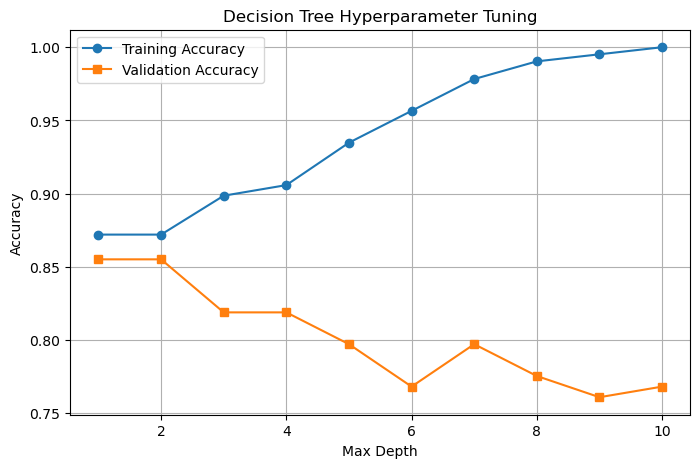

In [36]:
plt.figure(figsize=(8,5))

plt.plot(
    max_depth_values,
    train_accuracy,
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    max_depth_values,
    validation_accuracy,
    marker="s",
    label="Validation Accuracy"
)

plt.xlabel("Max Depth")
plt.ylabel("Accuracy")
plt.title("Decision Tree Hyperparameter Tuning")

plt.legend()

plt.grid(True)

plt.show()

## Create Basic Classification Models

Initialize the basic machine learning classification models that will be compared.

In [37]:
basic_models = {

    "Logistic Regression": LogisticRegression(random_state=42),

    "Decision Tree": DecisionTreeClassifier(
        max_depth=4,
        random_state=42
    ),

    "KNN": KNeighborsClassifier(
        n_neighbors=5
    ),

    "SVM": SVC(
        probability=True,
        random_state=42
    )

}

## Evaluate the Basic Models

Train and evaluate each basic classification model using the helper evaluation function.

In [38]:
basic_results = []

for name, model in basic_models.items():

    result = evaluate_model(

        model,

        X_train_scaled,

        X_val_scaled,

        y_train,

        y_val

    )

    result["Model"] = name

    basic_results.append(result)

LogisticRegression
Training Accuracy  : 0.8986
Validation Accuracy: 0.8261
Precision          : 0.8033
Recall             : 0.8033
F1 Score           : 0.8033
ROC-AUC            : 0.9314
DecisionTreeClassifier
Training Accuracy  : 0.9058
Validation Accuracy: 0.8188
Precision          : 0.7812
Recall             : 0.8197
F1 Score           : 0.8000
ROC-AUC            : 0.8181
KNeighborsClassifier
Training Accuracy  : 0.8961
Validation Accuracy: 0.8478
Precision          : 0.8571
Recall             : 0.7869
F1 Score           : 0.8205
ROC-AUC            : 0.9061
SVC
Training Accuracy  : 0.9300
Validation Accuracy: 0.8551
Precision          : 0.8060
Recall             : 0.8852
F1 Score           : 0.8438
ROC-AUC            : 0.9093


## Create the Results Table

Convert the evaluation results into a pandas DataFrame.

In [39]:
basic_results = pd.DataFrame(basic_results)

basic_results

,Model,Train Accuracy,Validation Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.898551,0.826087,0.803279,0.803279,0.803279,0.931446
1,Decision Tree,0.905797,0.818841,0.781250,0.819672,0.800000,0.818075
2,KNN,0.896135,0.847826,0.857143,0.786885,0.820513,0.906110
3,SVM,0.929952,0.855072,0.805970,0.885246,0.843750,0.909304


## Sort Models by Validation Accuracy

Sort the models according to their validation accuracy.

In [40]:
basic_results = basic_results.sort_values(

    by="Validation Accuracy",

    ascending=False,

    ignore_index=True

)

basic_results

,Model,Train Accuracy,Validation Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,SVM,0.929952,0.855072,0.805970,0.885246,0.843750,0.909304
1,KNN,0.896135,0.847826,0.857143,0.786885,0.820513,0.906110
2,Logistic Regression,0.898551,0.826087,0.803279,0.803279,0.803279,0.931446
3,Decision Tree,0.905797,0.818841,0.781250,0.819672,0.800000,0.818075


## Visualize the Basic Model Performance

Compare the validation accuracy of the basic classification models.

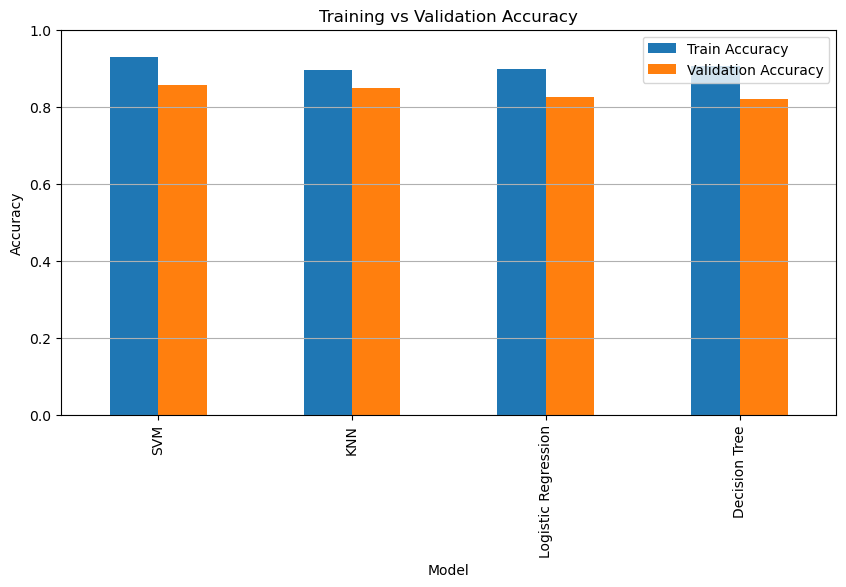

In [43]:
basic_results.plot(
    x="Model",
    y=["Train Accuracy", "Validation Accuracy"],
    kind="bar",
    figsize=(10,5)
)

plt.ylabel("Accuracy")

plt.title("Training vs Validation Accuracy")

plt.ylim(0,1)

plt.grid(axis="y")

plt.show()

## Ensemble Learning Models

Evaluate and compare ensemble learning techniques to improve prediction performance.

## Voting Classifier

Combine the predictions of multiple classifiers using majority voting.

In [45]:
voting_model = VotingClassifier(

    estimators=[

        ("Logistic Regression", LogisticRegression(random_state=42)),

        ("Decision Tree", DecisionTreeClassifier(max_depth=4, random_state=42)),

        ("KNN", KNeighborsClassifier(n_neighbors=5)),

        ("SVM", SVC(probability=True, random_state=42))

    ],

    voting="hard"

)

## Evaluate Voting Classifier

In [46]:
voting_result = evaluate_model(

    voting_model,

    X_train_scaled,

    X_val_scaled,

    y_train,

    y_val

)

VotingClassifier
Training Accuracy  : 0.9179
Validation Accuracy: 0.8116
Precision          : 0.7869
Recall             : 0.7869
F1 Score           : 0.7869


## Bagging Classifier

Train a Bagging classifier using Logistic Regression as the base estimator.

In [47]:
bagging_model = BaggingClassifier(

    estimator=LogisticRegression(random_state=42),

    n_estimators=100,

    max_samples=0.75,

    bootstrap=True,

    random_state=42,

    n_jobs=-1

)

## Evaluate Bagging Classifier

In [48]:
bagging_result = evaluate_model(

    bagging_model,

    X_train_scaled,

    X_val_scaled,

    y_train,

    y_val

)

BaggingClassifier
Training Accuracy  : 0.8937
Validation Accuracy: 0.8333
Precision          : 0.8167
Recall             : 0.8033
F1 Score           : 0.8099
ROC-AUC            : 0.9306


## Hyperparameter Tuning for Bagging Classifier

Evaluate different values of `n_estimators` to determine the optimal number of base estimators for the Bagging classifier.

In [49]:
n_estimators_values = [20, 40, 60, 80, 100, 120, 140, 160]

train_accuracy = []
validation_accuracy = []

for n in n_estimators_values:

    model = BaggingClassifier(
        estimator=LogisticRegression(random_state=42),
        n_estimators=n,
        max_samples=0.75,
        bootstrap=True,
        random_state=42,
        n_jobs=-1
    )

    result = evaluate_model(
        model,
        X_train_scaled,
        X_val_scaled,
        y_train,
        y_val
    )

    train_accuracy.append(result["Train Accuracy"])
    validation_accuracy.append(result["Validation Accuracy"])

BaggingClassifier
Training Accuracy  : 0.8986
Validation Accuracy: 0.8478
Precision          : 0.8333
Recall             : 0.8197
F1 Score           : 0.8264
ROC-AUC            : 0.9304
BaggingClassifier
Training Accuracy  : 0.8937
Validation Accuracy: 0.8261
Precision          : 0.8033
Recall             : 0.8033
F1 Score           : 0.8033
ROC-AUC            : 0.9312
BaggingClassifier
Training Accuracy  : 0.8937
Validation Accuracy: 0.8261
Precision          : 0.8033
Recall             : 0.8033
F1 Score           : 0.8033
ROC-AUC            : 0.9306
BaggingClassifier
Training Accuracy  : 0.8937
Validation Accuracy: 0.8333
Precision          : 0.8167
Recall             : 0.8033
F1 Score           : 0.8099
ROC-AUC            : 0.9304
BaggingClassifier
Training Accuracy  : 0.8937
Validation Accuracy: 0.8333
Precision          : 0.8167
Recall             : 0.8033
F1 Score           : 0.8099
ROC-AUC            : 0.9306
BaggingClassifier
Training Accuracy  : 0.8937
Validation Accuracy: 0.8

## Visualize Bagging Performance

Compare the training and validation accuracy for different numbers of estimators.

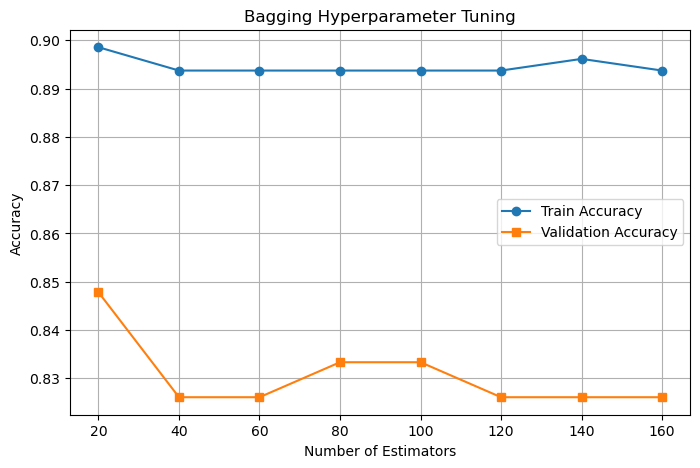

In [50]:
plt.figure(figsize=(8,5))

plt.plot(
    n_estimators_values,
    train_accuracy,
    marker="o",
    label="Train Accuracy"
)

plt.plot(
    n_estimators_values,
    validation_accuracy,
    marker="s",
    label="Validation Accuracy"
)

plt.xlabel("Number of Estimators")

plt.ylabel("Accuracy")

plt.title("Bagging Hyperparameter Tuning")

plt.legend()

plt.grid(True)

plt.show()

## Train the Best Bagging Model

Create the Bagging classifier using the best value of `n_estimators` obtained from the validation results.

In [51]:
bagging_model = BaggingClassifier(
    estimator=LogisticRegression(random_state=42),
    n_estimators=100,
    max_samples=0.75,
    bootstrap=True,
    random_state=42,
    n_jobs=-1
)

bagging_result = evaluate_model(
    bagging_model,
    X_train_scaled,
    X_val_scaled,
    y_train,
    y_val
)

BaggingClassifier
Training Accuracy  : 0.8937
Validation Accuracy: 0.8333
Precision          : 0.8167
Recall             : 0.8033
F1 Score           : 0.8099
ROC-AUC            : 0.9306


## Random Forest Classifier

In [52]:
random_forest_model = RandomForestClassifier(

    n_estimators=250,

    max_depth=6,

    random_state=42

)

## Evaluate Random Forest

In [53]:
random_forest_result = evaluate_model(

    random_forest_model,

    X_train_scaled,

    X_val_scaled,

    y_train,

    y_val

)

RandomForestClassifier
Training Accuracy  : 0.9638
Validation Accuracy: 0.8551
Precision          : 0.8596
Recall             : 0.8033
F1 Score           : 0.8305
ROC-AUC            : 0.9231


## Hyperparameter Tuning for Random Forest

Evaluate different values of `max_depth` to determine the optimal tree depth.

In [56]:
max_depth_values = range(1,11)

train_accuracy = []

validation_accuracy = []

for depth in max_depth_values:

    model = RandomForestClassifier(

        n_estimators=250,

        max_depth=depth,

        random_state=42

    )

    result = evaluate_model(

        model,

        X_train_scaled,

        X_val_scaled,

        y_train,

        y_val

    )

    train_accuracy.append(result["Train Accuracy"])

    validation_accuracy.append(result["Validation Accuracy"])

RandomForestClassifier
Training Accuracy  : 0.8744
Validation Accuracy: 0.8188
Precision          : 0.8600
Recall             : 0.7049
F1 Score           : 0.7748
ROC-AUC            : 0.9153
RandomForestClassifier
Training Accuracy  : 0.8961
Validation Accuracy: 0.8406
Precision          : 0.8679
Recall             : 0.7541
F1 Score           : 0.8070
ROC-AUC            : 0.9187
RandomForestClassifier
Training Accuracy  : 0.9082
Validation Accuracy: 0.8333
Precision          : 0.8654
Recall             : 0.7377
F1 Score           : 0.7965
ROC-AUC            : 0.9276
RandomForestClassifier
Training Accuracy  : 0.9179
Validation Accuracy: 0.8623
Precision          : 0.8750
Recall             : 0.8033
F1 Score           : 0.8376
ROC-AUC            : 0.9229
RandomForestClassifier
Training Accuracy  : 0.9420
Validation Accuracy: 0.8551
Precision          : 0.8596
Recall             : 0.8033
F1 Score           : 0.8305
ROC-AUC            : 0.9204
RandomForestClassifier
Training Accuracy  : 0

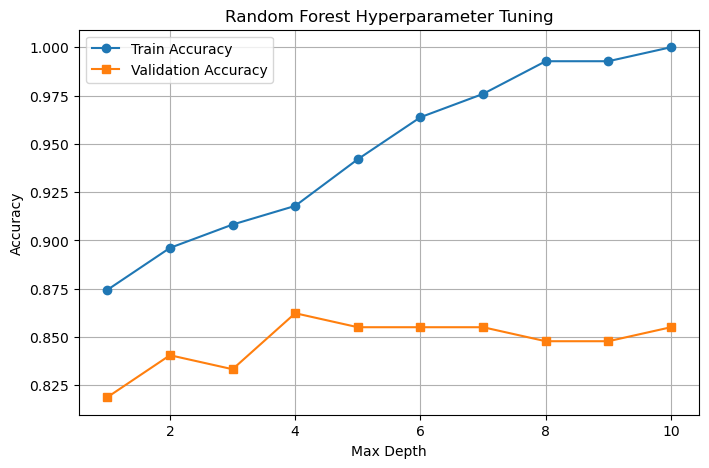

In [57]:
plt.figure(figsize=(8,5))

plt.plot(
    max_depth_values,
    train_accuracy,
    marker="o",
    label="Train Accuracy"
)

plt.plot(
    max_depth_values,
    validation_accuracy,
    marker="s",
    label="Validation Accuracy"
)

plt.xlabel("Max Depth")

plt.ylabel("Accuracy")

plt.title("Random Forest Hyperparameter Tuning")

plt.legend()

plt.grid(True)

plt.show()

## Extra Trees Classifier

In [54]:
extra_trees_model = ExtraTreesClassifier(

    n_estimators=250,

    max_depth=7,

    random_state=42

)

## Evaluate Extra Trees

In [55]:
extra_trees_result = evaluate_model(

    extra_trees_model,

    X_train_scaled,

    X_val_scaled,

    y_train,

    y_val

)

ExtraTreesClassifier
Training Accuracy  : 0.9420
Validation Accuracy: 0.8623
Precision          : 0.8387
Recall             : 0.8525
F1 Score           : 0.8455
ROC-AUC            : 0.9170


## Hyperparameter Tuning for Extra Trees

In [58]:
max_depth_values = range(1, 11)

train_accuracy = []
validation_accuracy = []

for depth in max_depth_values:

    model = ExtraTreesClassifier(
        n_estimators=250,
        max_depth=depth,
        random_state=42
    )

    result = evaluate_model(
        model,
        X_train_scaled,
        X_val_scaled,
        y_train,
        y_val
    )

    train_accuracy.append(result["Train Accuracy"])
    validation_accuracy.append(result["Validation Accuracy"])

ExtraTreesClassifier
Training Accuracy  : 0.8744
Validation Accuracy: 0.8478
Precision          : 0.8846
Recall             : 0.7541
F1 Score           : 0.8142
ROC-AUC            : 0.9165
ExtraTreesClassifier
Training Accuracy  : 0.8889
Validation Accuracy: 0.8696
Precision          : 0.8525
Recall             : 0.8525
F1 Score           : 0.8525
ROC-AUC            : 0.9161
ExtraTreesClassifier
Training Accuracy  : 0.8937
Validation Accuracy: 0.8768
Precision          : 0.8548
Recall             : 0.8689
F1 Score           : 0.8618
ROC-AUC            : 0.9131
ExtraTreesClassifier
Training Accuracy  : 0.9034
Validation Accuracy: 0.8696
Precision          : 0.8308
Recall             : 0.8852
F1 Score           : 0.8571
ROC-AUC            : 0.9180
ExtraTreesClassifier
Training Accuracy  : 0.9227
Validation Accuracy: 0.8623
Precision          : 0.8281
Recall             : 0.8689
F1 Score           : 0.8480
ROC-AUC            : 0.9182
ExtraTreesClassifier
Training Accuracy  : 0.9372
Valida

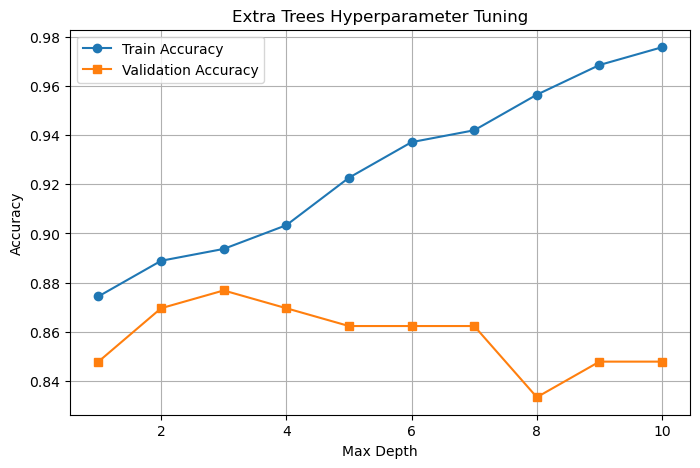

In [59]:
plt.figure(figsize=(8,5))

plt.plot(
    max_depth_values,
    train_accuracy,
    marker="o",
    label="Train Accuracy"
)

plt.plot(
    max_depth_values,
    validation_accuracy,
    marker="s",
    label="Validation Accuracy"
)

plt.xlabel("Max Depth")
plt.ylabel("Accuracy")
plt.title("Extra Trees Hyperparameter Tuning")

plt.legend()
plt.grid(True)
plt.show()

## AdaBoost Classifier

In [60]:
adaboost_model = AdaBoostClassifier(

    estimator=DecisionTreeClassifier(

        max_depth=3,

        min_samples_leaf=20,

        random_state=42

    ),

    n_estimators=300,

    learning_rate=0.05,

    random_state=42

)

## Evaluate AdaBoost

In [61]:
adaboost_result = evaluate_model(

    adaboost_model,

    X_train_scaled,

    X_val_scaled,

    y_train,

    y_val

)

AdaBoostClassifier
Training Accuracy  : 0.9493
Validation Accuracy: 0.8623
Precision          : 0.8889
Recall             : 0.7869
F1 Score           : 0.8348
ROC-AUC            : 0.9197


## Gradient Boosting Classifier

In [62]:
gradient_boosting_model = GradientBoostingClassifier(

    n_estimators=300,

    learning_rate=0.1,

    max_depth=1,

    random_state=42

)

## Evaluate Gradient Boosting

In [63]:
gradient_boosting_result = evaluate_model(

    gradient_boosting_model,

    X_train_scaled,

    X_val_scaled,

    y_train,

    y_val

)

GradientBoostingClassifier
Training Accuracy  : 0.9300
Validation Accuracy: 0.8768
Precision          : 0.8548
Recall             : 0.8689
F1 Score           : 0.8618
ROC-AUC            : 0.9224


## Gathering Ensemble Results 

In [65]:
ensemble_results = pd.DataFrame([
    voting_result,
    bagging_result,
    random_forest_result,
    extra_trees_result,
    adaboost_result,
    gradient_boosting_result
])

ensemble_results

,Model,Train Accuracy,Validation Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,VotingClassifier,0.917874,0.811594,0.786885,0.786885,0.786885,NaN
1,BaggingClassifier,0.893720,0.833333,0.816667,0.803279,0.809917,0.930594
2,RandomForestClassifier,0.963768,0.855072,0.859649,0.803279,0.830508,0.923142
3,ExtraTreesClassifier,0.942029,0.862319,0.838710,0.852459,0.845528,0.916968
4,AdaBoostClassifier,0.949275,0.862319,0.888889,0.786885,0.834783,0.919736
5,GradientBoostingClassifier,0.929952,0.876812,0.854839,0.868852,0.861789,0.922397


## Compare All Models

Combine the evaluation results of all basic and ensemble learning models into a single table.

In [66]:
all_results = pd.concat(
    [basic_results, ensemble_results],
    ignore_index=True
)

all_results

,Model,Train Accuracy,Validation Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,SVM,0.929952,0.855072,0.805970,0.885246,0.843750,0.909304
1,KNN,0.896135,0.847826,0.857143,0.786885,0.820513,0.906110
2,Logistic Regression,0.898551,0.826087,0.803279,0.803279,0.803279,0.931446
3,Decision Tree,0.905797,0.818841,0.781250,0.819672,0.800000,0.818075
4,VotingClassifier,0.917874,0.811594,0.786885,0.786885,0.786885,NaN
5,BaggingClassifier,0.893720,0.833333,0.816667,0.803279,0.809917,0.930594
6,RandomForestClassifier,0.963768,0.855072,0.859649,0.803279,0.830508,0.923142
7,ExtraTreesClassifier,0.942029,0.862319,0.838710,0.852459,0.845528,0.916968
8,AdaBoostClassifier,0.949275,0.862319,0.888889,0.786885,0.834783,0.919736
9,GradientBoostingClassifier,0.929952,0.876812,0.854839,0.868852,0.861789,0.922397


## Sort Models by Validation Accuracy

Display the models in descending order according to their validation accuracy.

In [69]:
all_results.sort_values(
    by="Validation Accuracy",
    ascending=False,
    ignore_index=True
)

,Model,Train Accuracy,Validation Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,GradientBoostingClassifier,0.929952,0.876812,0.854839,0.868852,0.861789,0.922397
1,AdaBoostClassifier,0.949275,0.862319,0.888889,0.786885,0.834783,0.919736
2,ExtraTreesClassifier,0.942029,0.862319,0.838710,0.852459,0.845528,0.916968
3,RandomForestClassifier,0.963768,0.855072,0.859649,0.803279,0.830508,0.923142
4,SVM,0.929952,0.855072,0.805970,0.885246,0.843750,0.909304
5,KNN,0.896135,0.847826,0.857143,0.786885,0.820513,0.906110
6,BaggingClassifier,0.893720,0.833333,0.816667,0.803279,0.809917,0.930594
7,Logistic Regression,0.898551,0.826087,0.803279,0.803279,0.803279,0.931446
8,Decision Tree,0.905797,0.818841,0.781250,0.819672,0.800000,0.818075
9,VotingClassifier,0.917874,0.811594,0.786885,0.786885,0.786885,NaN


## Sort Models by Training Accuracy

In [70]:
all_results.sort_values(
    by="Train Accuracy",
    ascending=False,
    ignore_index=True
)

,Model,Train Accuracy,Validation Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,RandomForestClassifier,0.963768,0.855072,0.859649,0.803279,0.830508,0.923142
1,AdaBoostClassifier,0.949275,0.862319,0.888889,0.786885,0.834783,0.919736
2,ExtraTreesClassifier,0.942029,0.862319,0.838710,0.852459,0.845528,0.916968
3,GradientBoostingClassifier,0.929952,0.876812,0.854839,0.868852,0.861789,0.922397
4,SVM,0.929952,0.855072,0.805970,0.885246,0.843750,0.909304
5,VotingClassifier,0.917874,0.811594,0.786885,0.786885,0.786885,NaN
6,Decision Tree,0.905797,0.818841,0.781250,0.819672,0.800000,0.818075
7,Logistic Regression,0.898551,0.826087,0.803279,0.803279,0.803279,0.931446
8,KNN,0.896135,0.847826,0.857143,0.786885,0.820513,0.906110
9,BaggingClassifier,0.893720,0.833333,0.816667,0.803279,0.809917,0.930594


## Visualize Model Performance

Compare the training and validation accuracy of all classification models.

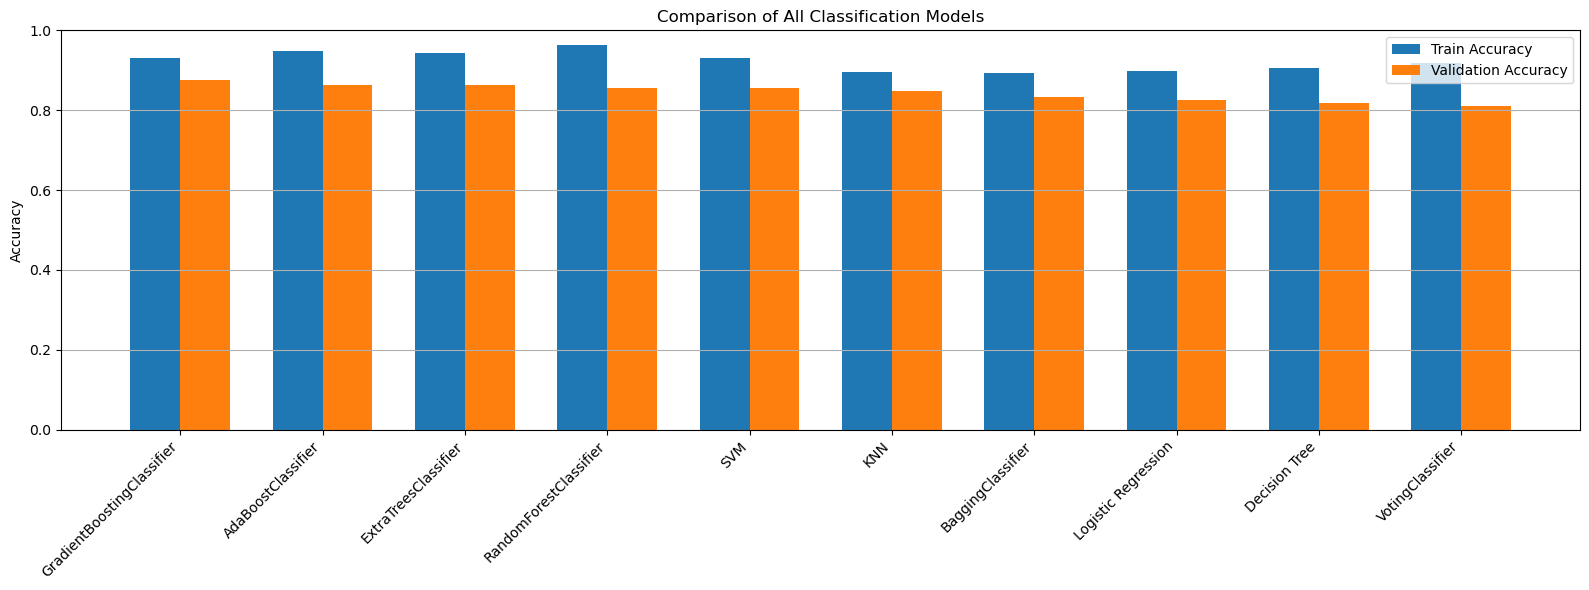

In [73]:
plt.figure(figsize=(16,6))

x = np.arange(len(all_results))
width = 0.35

plt.bar(
    x - width/2,
    all_results["Train Accuracy"],
    width,
    label="Train Accuracy"
)

plt.bar(
    x + width/2,
    all_results["Validation Accuracy"],
    width,
    label="Validation Accuracy"
)

plt.xticks(
    x,
    all_results["Model"],
    rotation=45,
    ha="right"
)

plt.ylabel("Accuracy")

plt.title("Comparison of All Classification Models")

plt.ylim(0,1)

plt.grid(axis="y")

plt.legend()

plt.tight_layout()

plt.show()

## Select the Best Model

Choose the model with the highest validation accuracy.

In [74]:
best_model_name = all_results.iloc[0]["Model"]

print("Best Model:", best_model_name)

Best Model: GradientBoostingClassifier


## Create the Best Model

Initialize the best-performing model before evaluating it on the test set.

In [75]:
best_model = GradientBoostingClassifier(
    n_estimators=300,
    learning_rate=0.1,
    max_depth=1,
    random_state=42
)

## Train the Best Model

In [76]:
best_model.fit(X_train_scaled, y_train)

,loss,'log_loss'
,learning_rate,0.1
,n_estimators,300
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,1
,min_impurity_decrease,0.0
,init,None


## Test Set Prediction

In [77]:
y_test_pred = best_model.predict(X_test_scaled)

## Test Accuracy

Calculate the prediction accuracy on the test dataset.

In [78]:
test_accuracy = accuracy_score(
    y_test,
    y_test_pred
)

print("Test Accuracy:", test_accuracy)

Test Accuracy: 0.8333333333333334


## Save the Best Model

Save the trained model for future prediction without retraining.

In [79]:
import pickle

with open("best_credit_card_model.pkl", "wb") as file:

    pickle.dump(best_model, file)

print("Model saved successfully.")

Model saved successfully.
